## **Ligand Curation**

### **Imports**

In [9]:
from rdkit import Chem
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit import RDLogger
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
target = 'pxr' # 'ahr', 'car', 'pxr'

In [ ]:
import os
from pathlib import Path
import sys

# Define xenotox as base directory
BASE_DIR = Path(f"{os.getcwd()}/..").resolve()

# Add parent directory to sys.path for imports
sys.path.append(str(BASE_DIR))

os.makedirs(f"{BASE_DIR}/ligands/{target}", exist_ok=True)


### **Load data**

In [4]:
import pandas as pd
outpath = f"{BASE_DIR}/ligands/{target}/datatable_all_{target}.csv"
csv = pd.read_csv(outpath)
selected_columns = ['CID', 'SMILES', 'Agonist_Activity', 'Agonist_Potency (uM)', 'Agonist_Efficacy (%)', 'Viability_Activity', 'Viability_Potency (uM)', 'Viability_Efficacy (%)']
df = csv[selected_columns]
df['Agonist_Activity'] = df['Agonist_Activity'].replace('active agonist', 'active')
df.info()
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9667 entries, 0 to 9666
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CID                     9524 non-null   float64
 1   SMILES                  9524 non-null   object 
 2   Agonist_Activity        9667 non-null   object 
 3   Agonist_Potency (uM)    2971 non-null   float64
 4   Agonist_Efficacy (%)    9080 non-null   float64
 5   Viability_Activity      9667 non-null   object 
 6   Viability_Potency (uM)  1702 non-null   float64
 7   Viability_Efficacy (%)  9534 non-null   float64
dtypes: float64(5), object(3)
memory usage: 604.3+ KB


C:\Users\elias\AppData\Local\Temp\ipykernel_2708\336108981.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Agonist_Activity'] = df['Agonist_Activity'].replace('active agonist', 'active')


,CID,SMILES,Agonist_Activity,Agonist_Potency (uM),Agonist_Efficacy (%),Viability_Activity,Viability_Potency (uM),Viability_Efficacy (%)
0,10219.0,CC[C@H]1CN2CCC3=CC(=C(C=C3[C@@H]2C[C@@H]1C[C@@...,active,0.033491,211.419434,active antagonist,0.037578,-58.1492
1,6708701.0,C[C@]12C3CCC([C@]1(C(=O)OC2=O)C)O3,active,1.019219,362.348497,active antagonist,0.237101,-73.1631
2,7594.0,C1=CC=C(C=C1)NC(=NC2=CC=CC=C2)N,active,4.867434,489.929447,active antagonist,5.649200,-54.6079
3,156414.0,C=CC(=O)NC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC(=C(C=C...,active,11.005271,655.906322,active antagonist,2.872550,-44.3797
4,5280443.0,C1=CC(=CC=C1C2=CC(=O)C3=C(C=C(C=C3O2)O)O)O,active,22.538503,949.440188,active antagonist,27.595500,-72.5478
5,3068143.0,CC[C@H]1CN2CCC3=CC(=C(C=C3[C@@H]2C[C@@H]1C[C@@...,active,0.045107,178.218276,active antagonist,0.068799,-69.0138
6,11254899.0,CCCC[N+]1=CC=C(C=C1)C.F[P-](F)(F)(F)(F)F,active,5.050874,457.884654,active antagonist,6.119270,-54.5569
7,9910986.0,CN1CC[C@@H]([C@@H](C1)O)C2=C(C=C(C3=C2OC(=CC3=...,active,0.090838,192.470436,active antagonist,0.074978,-58.6109
8,5280443.0,C1=CC(=CC=C1C2=CC(=O)C3=C(C=C(C=C3O2)O)O)O,active,21.149586,852.862703,active antagonist,35.046600,-81.2788
9,7594.0,C1=CC=C(C=C1)NC(=NC2=CC=CC=C2)N,active,8.741798,488.594105,active antagonist,9.439180,-47.3489


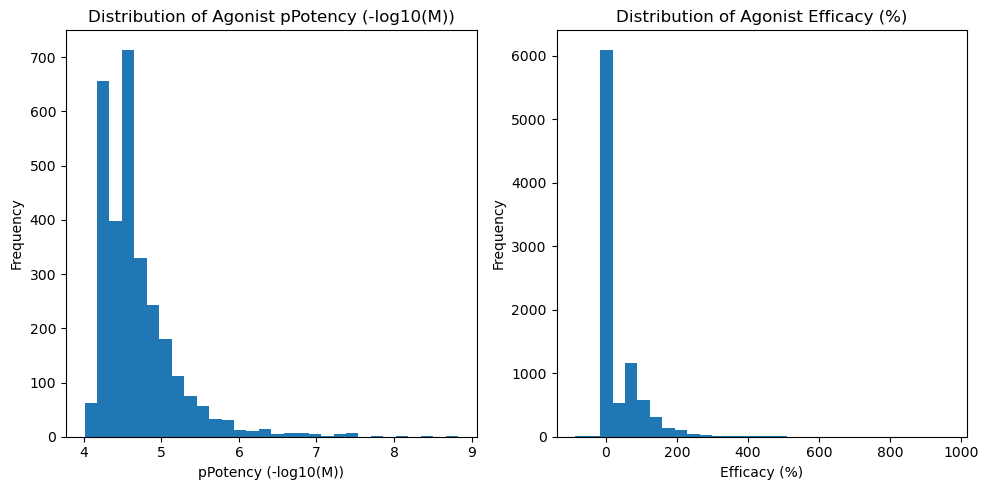

In [11]:
# Distribution of potency and efficacy
potency =-np.log10(df["Agonist_Potency (uM)"] * 1e-6)
efficacy = df["Agonist_Efficacy (%)"]

# Create figure
plt.figure(figsize=(10, 5))

# Subplot 1: Potency distribution
plt.subplot(1, 2, 1)
plt.hist(potency.dropna(), bins=30)
plt.title("Distribution of Agonist pPotency (-log10(M))")
plt.xlabel("pPotency (-log10(M))")
plt.ylabel("Frequency")

# Subplot 2: Efficacy distribution
plt.subplot(1, 2, 2)
plt.hist(efficacy.dropna(), bins=30)
plt.title("Distribution of Agonist Efficacy (%)")
plt.xlabel("Efficacy (%)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### **Curation**


In [ ]:
from utils_clf.ligand_curation import curation
df_qsar, curation_report_df, std_report_df = curation('SMILES', df)

print(df_qsar)
print(curation_report_df)
print(std_report_df)

# Save
df_qsar.to_csv(f'{BASE_DIR}/ligands/{target}/{target}_ligands.csv', index=False)
curation_report_df.to_csv(f'{BASE_DIR}/ligands/{target}/{target}_curation_report.csv', index=False)
std_report_df.to_csv(f'{BASE_DIR}/ligands/{target}/{target}_standarization_report.csv', index=False)



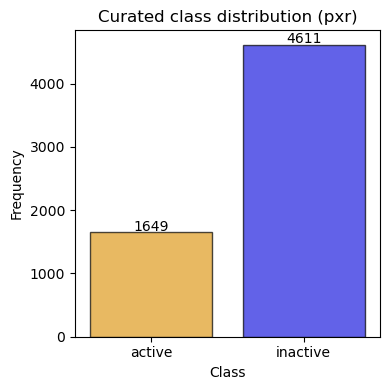

In [ ]:
from utils_clf.class_distribution import plot_class_distribution
plot = plot_class_distribution(df_qsar, "Agonist_Activity", target)

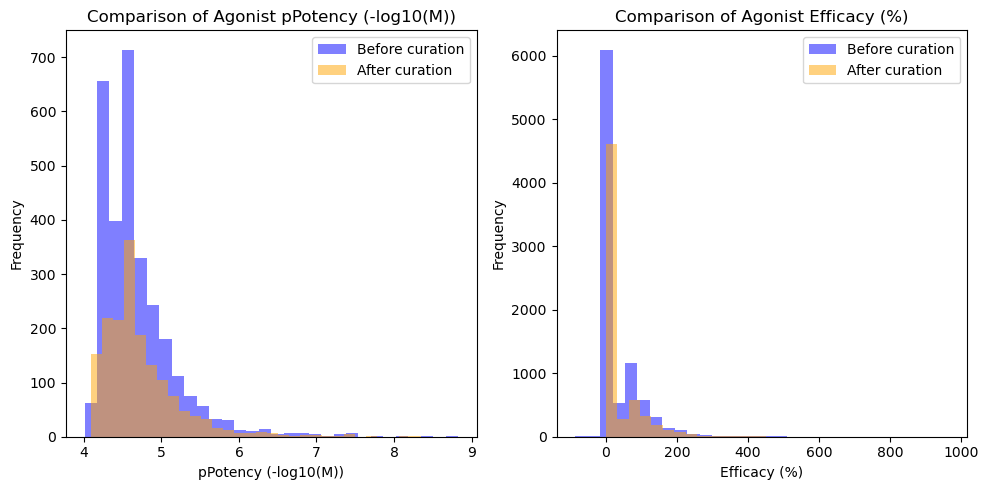

In [24]:
# Comparison of distributions before and after curation
# Compute potency and efficacy for before curation
potency_before = -np.log10(df["Agonist_Potency (uM)"] * 1e-6)
efficacy_before = df["Agonist_Efficacy (%)"]

# Compute potency and efficacy for after curation
potency_after = -np.log10(df_qsar["Agonist_Potency (uM)"] * 1e-6)
efficacy_after = df_qsar["Agonist_Efficacy (%)"]

# Create figure with subplots
plt.figure(figsize=(10, 5))

# Subplot 1: Potency comparison
plt.subplot(1, 2, 1)
plt.hist(potency_before.dropna(), bins=30, alpha=0.5, label='Before curation', color='blue')
plt.hist(potency_after.dropna(), bins=30, alpha=0.5, label='After curation', color='orange')
plt.title("Comparison of Agonist pPotency (-log10(M))")
plt.xlabel("pPotency (-log10(M))")
plt.ylabel("Frequency")
plt.legend()

# Subplot 2: Efficacy comparison
plt.subplot(1, 2, 2)
plt.hist(efficacy_before.dropna(), bins=30, alpha=0.5, label='Before curation', color='blue')
plt.hist(efficacy_after.dropna(), bins=30, alpha=0.5, label='After curation', color='orange')
plt.title("Comparison of Agonist Efficacy (%)")
plt.xlabel("Efficacy (%)")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/ligands/{target}/{target}_potency_efficacy_comparison.png', dpi=300)
plt.show()

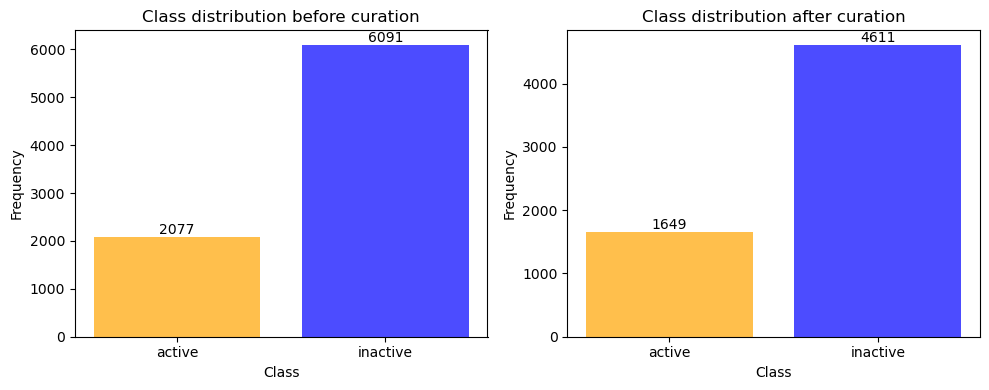

In [30]:
# Comparison of class distributions before and after curation
# Compute counts for before curation (only active and inactive)
before_counts = df[df["Agonist_Activity"].isin(["active", "inactive"])]["Agonist_Activity"].value_counts().sort_index()

# Compute counts for after curation
after_counts = df_qsar["Agonist_Activity"].value_counts().sort_index()

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Colors: orange for active, blue for inactive
colors_before = ['orange' if label == 'active' else 'blue' for label in before_counts.index]
colors_after = ['orange' if label == 'active' else 'blue' for label in after_counts.index]

# Before curation
axes[0].bar(before_counts.index, before_counts.values, color=colors_before, alpha=0.7)
axes[0].set_title("Class distribution before curation")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Frequency")
for i, v in enumerate(before_counts.values):
    axes[0].text(i, v + max(before_counts.values) * 0.01, str(v), ha='center')

# After curation
axes[1].bar(after_counts.index, after_counts.values, color=colors_after, alpha=0.7)
axes[1].set_title("Class distribution after curation")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Frequency")
for i, v in enumerate(after_counts.values):
    axes[1].text(i, v + max(after_counts.values) * 0.01, str(v), ha='center')

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/ligands/{target}/{target}_class_dist_comparison.png', dpi=300)
plt.show()